<a href="https://colab.research.google.com/github/noha-adam-1011/Project-1/blob/main/EDA_Mini_Project_Noha_Ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1.uploading the file
from google.colab import files
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
print('file has been uploaded successfully')

Saving Sample - Superstore 2019(Orders) (1).csv to Sample - Superstore 2019(Orders) (1).csv
file has been uploaded successfully


In [ ]:
#2.Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('All libraries have been uploaded')

All libraries have been uploaded


In [ ]:
#3.Reading the file
from IPython.lib.security import encode
def read_dataset(path: str):
  try:
   try:
     try:
       df = pd.read_csv(path,encoding='utf-8')
     except UnicodeDecodeError:
        print('utf-8 Incompatible Encoding')
        df = pd.read_csv(path,encoding='latin1')
        print(f'file has been upoloade successfully as follows {df.shape[0]} rows x {df.shape[1]} columns')
     return df
   except TypeError:
    print('Not a CSV file')
    df = pd.read_excel(path)
    print(f'file has been upoloade successfully as follows {df.shape[0]} rows x {df.shape[1]} columns')
    return df
  except FileNotFoundError:
    print("upload file")

In [ ]:
raw_data = read_dataset(file_path)
raw_data

utf-8 Incompatible Encoding
file has been upoloade successfully as follows 9996 rows x 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2018-152156,11/8/2018,11/11/2018,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2.0,CA-2018-152156,11/8/2018,11/11/2018,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3.0,CA-2018-138688,6/12/2018,6/16/2018,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4.0,US-2017-108966,10/11/2017,10/18/2017,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5.0,US-2017-108966,10/11/2017,10/18/2017,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,9992.0,CA-2019-121258,2/26/2019,3/3/2019,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2.0,0.20,19.3932
9992,9993.0,CA-2019-121258,2/26/2019,3/3/2019,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4.0,0.00,13.3200
9993,9994.0,CA-2019-119914,5/4/2019,5/9/2019,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.1600,2.0,0.00,72.9480
9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#4. General Info about the dataset
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9994 non-null   float64
 1   Order ID        9994 non-null   object 
 2   Order Date      9994 non-null   object 
 3   Ship Date       9994 non-null   object 
 4   Ship Mode       9994 non-null   object 
 5   Customer ID     9994 non-null   object 
 6   Customer Name   9994 non-null   object 
 7   Segment         9994 non-null   object 
 8   Country/Region  9994 non-null   object 
 9   City            9994 non-null   object 
 10  State           9994 non-null   object 
 11  Postal Code     9983 non-null   float64
 12  Region          9994 non-null   object 
 13  Product ID      9994 non-null   object 
 14  Category        9994 non-null   object 
 15  Sub-Category    9994 non-null   object 
 16  Product Name    9994 non-null   object 
 17  Sales           9994 non-null   f

In [ ]:
#5.Duplicates Check and Removal
def remove_duplicates(data : pd.DataFrame):
  try:
    before = len(data)
    cleaned = len(data.drop_duplicates().reset_index(drop=True))
    print('Number of duplicate rows dropped: ', str(before - cleaned))
    return data.drop_duplicates().reset_index(drop=True)
  except Exception as e:
    print(f'there is an error {e}')

In [ ]:
raw_data_1= remove_duplicates(raw_data)

Number of duplicate rows dropped:  1


In [ ]:
#5.Removing Rows where all values are Nulls
def remove_null_rows (data : pd.DataFrame):
  try:
    before = len(data)
    cleaned = len(data.dropna(how='all').reset_index(drop=True))
    print('Number of rows dropped: ', str(before - cleaned))
    return data.dropna(how='all').reset_index(drop=True)
  except Exception as e:
    print(f'there is an error {e}')

In [ ]:
raw_data_2 = remove_null_rows(raw_data_1)

Number of rows dropped:  1


In [ ]:
#6. Nulls Check
def check_nulls(data : pd.DataFrame):
  try:
    data.isnull().sum()
    return data.isnull().sum()
  except Exception as e:
    print(f'there is an error {e}')

In [ ]:
check_nulls(raw_data_2)

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [ ]:
#7.Statistical Describtion
def describe_data(data : pd.DataFrame):
  try:
    return data.describe()
  except Exception as e:
    print(f'there is an error {e}')

In [ ]:
describe_data(raw_data_2).T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9983.0,55245.233297,32038.715955,1040.000,23223.00000,57103.0000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [ ]:
#8.Handeling Missing Values
def missing_values_fix (data : pd.DataFrame,numeric_strategy = 'median'):
  try:
    data = data.copy()
    numeric_cols = data.select_dtypes(include= np.number).columns
    categorical_cols = data.select_dtypes(include='object').columns
    for col in numeric_cols:
      if data[col].isnull().sum() > 0:
        if numeric_strategy == 'median':
          data[col] = data[col].fillna(data[col].median())
        else:
          data[col] = data[col].fillna(data[col].mean())
    for col in categorical_cols:
      if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])
    print('All missing values have been handled')
  except Exception as e:
    print(f'there is an error {e}')
  return data


In [ ]:
raw_data_3 = missing_values_fix(raw_data_2)
print(raw_data_3)

All missing values have been handled
      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0        1.0  CA-2018-152156   11/8/2018  11/11/2018    Second Class   
1        2.0  CA-2018-152156   11/8/2018  11/11/2018    Second Class   
2        3.0  CA-2018-138688   6/12/2018   6/16/2018    Second Class   
3        4.0  US-2017-108966  10/11/2017  10/18/2017  Standard Class   
4        5.0  US-2017-108966  10/11/2017  10/18/2017  Standard Class   
...      ...             ...         ...         ...             ...   
9989  9990.0  CA-2016-110422   1/21/2016   1/23/2016    Second Class   
9990  9991.0  CA-2019-121258   2/26/2019    3/3/2019  Standard Class   
9991  9992.0  CA-2019-121258   2/26/2019    3/3/2019  Standard Class   
9992  9993.0  CA-2019-121258   2/26/2019    3/3/2019  Standard Class   
9993  9994.0  CA-2019-119914    5/4/2019    5/9/2019    Second Class   

     Customer ID     Customer Name    Segment Country/Region             City  \
0       CG-12520 

In [ ]:
#9.Missing Value Re-check
check_nulls(raw_data_3)

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [ ]:
#10. Inconsistent Date Format Check
def check_date_format(data : pd.DataFrame, date_column : str):
  date = pd.to_datetime(data[date_column], errors='coerce')
  invalid_date = data[date.isna()]
  return invalid_date

In [ ]:
check_date_format(raw_data_3,'Ship Date')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [ ]:
check_date_format(raw_data_3,'Order Date')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [ ]:
#11.Shipping Duration Column Addition
raw_data_3['Order Date'] = pd.to_datetime(raw_data_3['Order Date'])
raw_data_3['Ship Date'] = pd.to_datetime(raw_data_3['Ship Date'])
raw_data_3['Shipping Duration in Days'] = (raw_data_3['Ship Date'] - raw_data_3['Order Date']).dt.days
raw_data_3

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Duration in Days
0,1.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,3
1,2.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,3
2,3.0,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,4
3,4.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,7
4,5.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990.0,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3.0,0.20,4.1028,2
9990,9991.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2.0,0.00,15.6332,5
9991,9992.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2.0,0.20,19.3932,5
9992,9993.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4.0,0.00,13.3200,5


In [ ]:
#12.Sales Category Columns
def sales_category_add(data:pd.DataFrame):
  try:
    data['Sales Category'] = pd.qcut(data['Sales'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
    return data
  except Exception as e:
    print(f'there is an error {e}')

In [ ]:
sales_category_add(raw_data_3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Duration in Days,Sales Category
0,1.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,3,Very High
1,2.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,3,Very High
2,3.0,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,4,Low
3,4.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,7,Very High
4,5.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,7,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990.0,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3.0,0.20,4.1028,2,Medium
9990,9991.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2.0,0.00,15.6332,5,High
9991,9992.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2.0,0.20,19.3932,5,Very High
9992,9993.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4.0,0.00,13.3200,5,Medium


In [ ]:
#13.Profit Margin column addition
raw_data_3['Profit Margin'] = (raw_data_3['Profit'] / raw_data_3['Sales'])*100
raw_data_3

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Duration in Days,Sales Category,Profit Margin
0,1.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,3,Very High,16.00
1,2.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,3,Very High,30.00
2,3.0,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,4,Low,47.00
3,4.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,7,Very High,-40.00
4,5.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,7,Medium,11.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990.0,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3.0,0.20,4.1028,2,Medium,16.25
9990,9991.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2.0,0.00,15.6332,5,High,17.00
9991,9992.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2.0,0.20,19.3932,5,Very High,7.50
9992,9993.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4.0,0.00,13.3200,5,Medium,45.00


In [ ]:
#14.Date Extraction
raw_data_3['Order Date'] = pd.to_datetime(raw_data_3['Order Date'])
raw_data_3['Order Year'] = raw_data_3['Order Date'].dt.year
raw_data_3['Order Month'] = raw_data_3['Order Date'].dt.month
raw_data_3['Order Day'] = raw_data_3['Order Date'].dt.day
raw_data_3['Order Month Name'] = raw_data_3['Order Date'].dt.month_name()
raw_data_3['Order Quarter'] = raw_data_3['Order Date'].dt.quarter

raw_data_3

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Discount,Profit,Shipping Duration in Days,Sales Category,Profit Margin,Order Year,Order Month,Order Day,Order Month Name,Order Quarter
0,1.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.9136,3,Very High,16.00,2018,11,8,November,4
1,2.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.5820,3,Very High,30.00,2018,11,8,November,4
2,3.0,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.8714,4,Low,47.00,2018,6,12,June,2
3,4.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.0310,7,Very High,-40.00,2017,10,11,October,4
4,5.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.5164,7,Medium,11.25,2017,10,11,October,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990.0,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,0.20,4.1028,2,Medium,16.25,2016,1,21,January,1
9990,9991.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,0.00,15.6332,5,High,17.00,2019,2,26,February,1
9991,9992.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,0.20,19.3932,5,Very High,7.50,2019,2,26,February,1
9992,9993.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,0.00,13.3200,5,Medium,45.00,2019,2,26,February,1


In [ ]:
#15.Fixing Negative Values
def fix_negative_values(data : pd.DataFrame):
  numeric_cols = data.select_dtypes(include= np.number).columns
  for col in numeric_cols:
    if data[col].min() < 0:
      data[col] = data[col].abs()
  return data

In [ ]:
fix_negative_values(raw_data_3 )

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Profit,Shipping Duration in Days,Sales Category,Profit Margin,Order Year,Order Month,Order Day,Order Month Name,Order Quarter,Full Address
0,1.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,41.9136,3,Very High,16.00,2018,11,8,November,4,Henderson-Kentucky-United States
1,2.0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,219.5820,3,Very High,30.00,2018,11,8,November,4,Henderson-Kentucky-United States
2,3.0,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,6.8714,4,Low,47.00,2018,6,12,June,2,Los Angeles-California-United States
3,4.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,383.0310,7,Very High,40.00,2017,10,11,October,4,Fort Lauderdale-Florida-United States
4,5.0,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2.5164,7,Medium,11.25,2017,10,11,October,4,Fort Lauderdale-Florida-United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990.0,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,4.1028,2,Medium,16.25,2016,1,21,January,1,Miami-Florida-United States
9990,9991.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,15.6332,5,High,17.00,2019,2,26,February,1,Costa Mesa-California-United States
9991,9992.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,19.3932,5,Very High,7.50,2019,2,26,February,1,Costa Mesa-California-United States
9992,9993.0,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,13.3200,5,Medium,45.00,2019,2,26,February,1,Costa Mesa-California-United States


In [ ]:
#16.Sales Grouping
Sales_Groups = raw_data_3.groupby('Sales Category').agg({'Order ID': 'count'}).reset_index
print(Sales_Groups)

<bound method DataFrame.reset_index of                 Order ID
Sales Category          
Low                 2501
Medium              2496
High                2499
Very High           2498>


/tmp/ipykernel_1861/1215471120.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Sales_Groups = raw_data_3.groupby('Sales Category').agg({'Order ID': 'count'}).reset_index


/tmp/ipykernel_1861/1914275151.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Order Month Name', y='Sales', data=MonthlySales, marker='o', palette='deep')


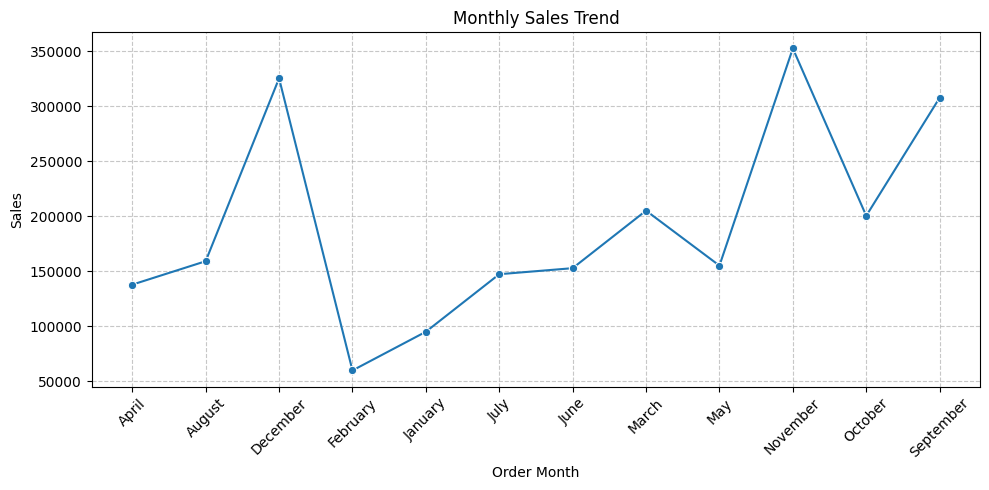

In [ ]:
#17.Sales Trend per Month
plt.figure(figsize=(10,5))
MonthlySales = raw_data_3.groupby('Order Month Name')['Sales'].sum().reset_index()
sns.lineplot(x='Order Month Name', y='Sales', data=MonthlySales, marker='o', palette='deep')
plt.xlabel('Order Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1861/3139087518.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order Quarter', y='Sales', data=QuarterlySales, palette='viridis')


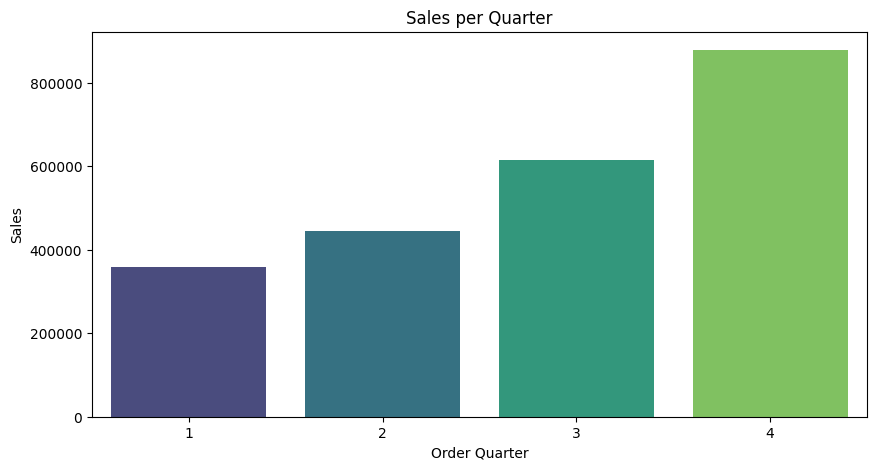

In [ ]:
#17.Sales per Quarter
plt.figure(figsize=(10,5))
QuarterlySales = raw_data_3.groupby('Order Quarter')['Sales'].sum().reset_index()
sns.barplot(x='Order Quarter', y='Sales', data=QuarterlySales, palette='viridis')
plt.xlabel('Order Quarter')
plt.ylabel('Sales')
plt.title('Sales per Quarter')
plt.show()

/tmp/ipykernel_1861/23688184.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Order Month Name', y='Profit', data=MonthlySales, marker='o', palette='deep')


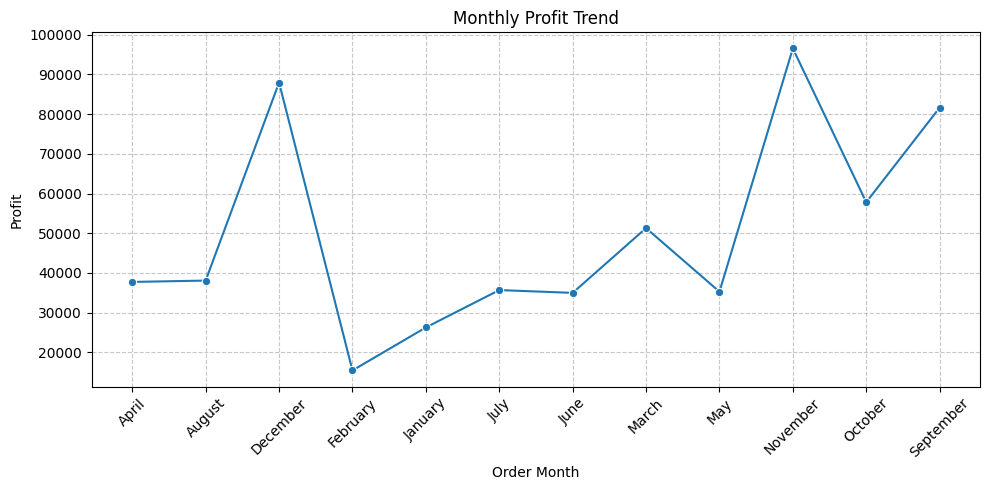

In [ ]:
#17.Profit Trend per Month
plt.figure(figsize=(10,5))
MonthlySales = raw_data_3.groupby('Order Month Name')['Profit'].sum().reset_index()
sns.lineplot(x='Order Month Name', y='Profit', data=MonthlySales, marker='o', palette='deep')
plt.xlabel('Order Month')
plt.ylabel('Profit')
plt.title('Monthly Profit Trend')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1861/1882916390.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Product Name', data=Top5ProductSales, palette='viridis')


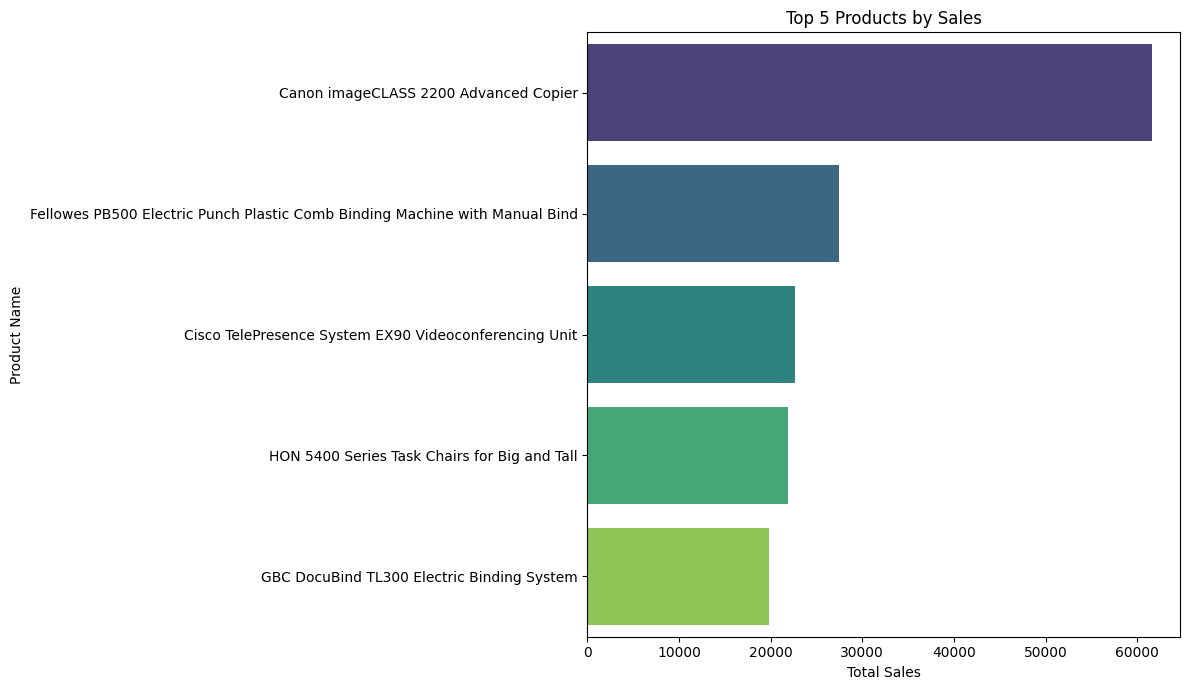

In [ ]:
#19.Top 5 products in Terms of Sales
plt.figure(figsize=(12,7))
ProductSales = raw_data_3.groupby('Product Name')['Sales'].sum().reset_index()
Top5ProductSales = ProductSales.nlargest(5, 'Sales')

sns.barplot(x='Sales', y='Product Name', data=Top5ProductSales, palette='viridis')

plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.title('Top 5 Products by Sales')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1861/1788717717.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Customer Name', data=Top5CstSales, palette='viridis')


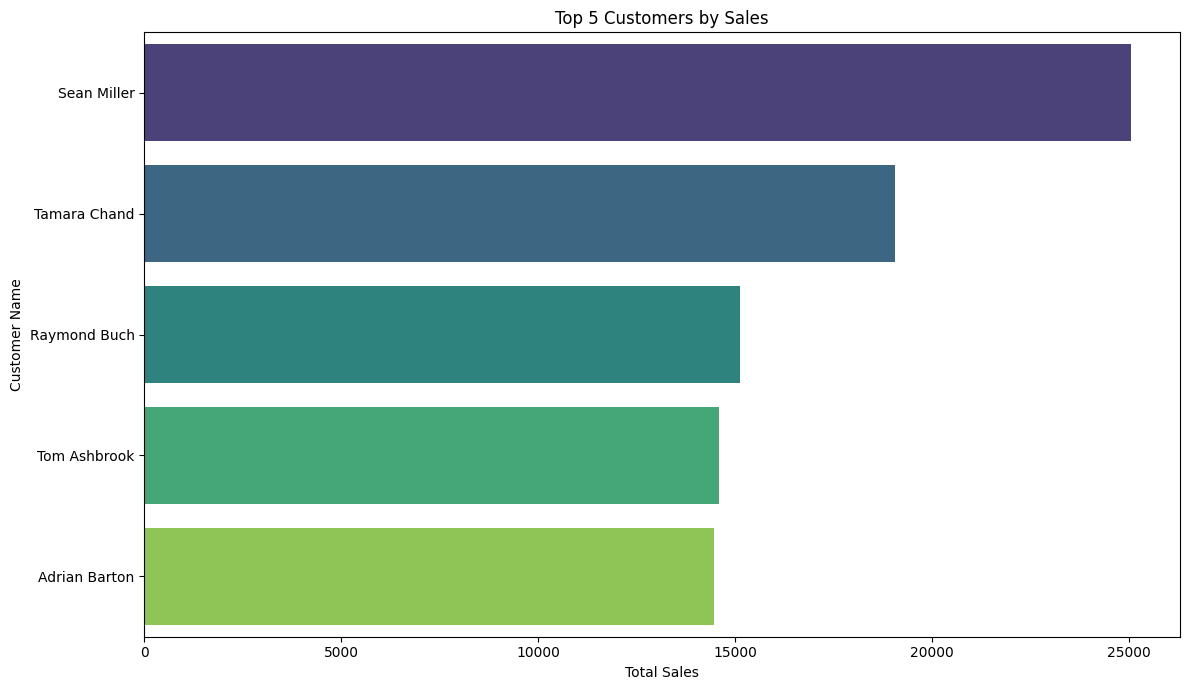

In [ ]:
#19.Top 5 Customers in Terms of Sales
plt.figure(figsize=(12,7))
CstSales = raw_data_3.groupby('Customer Name')['Sales'].sum().reset_index()
Top5CstSales = CstSales.nlargest(5, 'Sales')

sns.barplot(x='Sales', y='Customer Name', data=Top5CstSales, palette='viridis')

plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.title('Top 5 Customers by Sales')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Total Orders per Customer Segment')

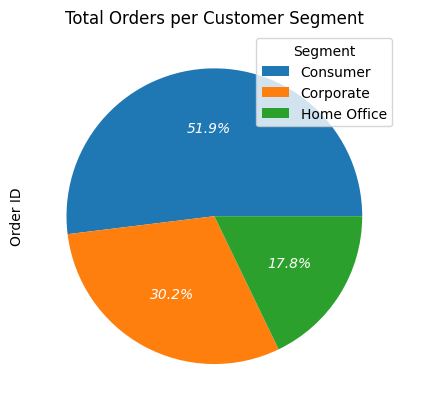

In [ ]:
#20.Which customer segment has the highest orders count?
CutomerSegmentation = raw_data_3.groupby('Segment')['Order ID'].count()
CutomerSegmentation.plot(kind='pie',autopct='%1.1f%%', textprops={"color":"white","style":"oblique"})
plt.legend(title="Segment", loc="best")
plt.title("Total Orders per Customer Segment")

Text(0.5, 1.0, 'Shipping Mode Distribution')

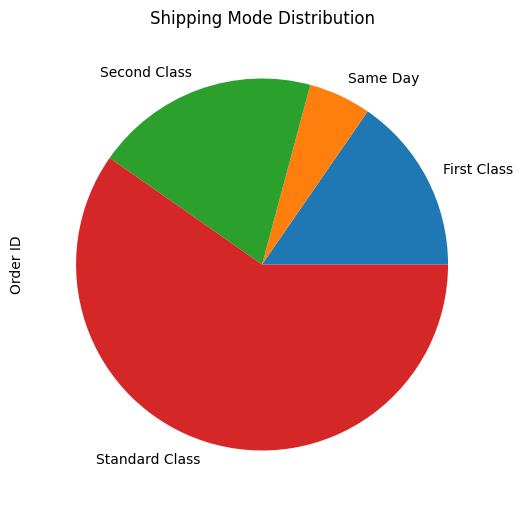

In [ ]:
#21.What is the most common shipping method?
Shipping_Mode = raw_data_3.groupby('Ship Mode')['Order ID'].count()
Shipping_Mode
plt.figure(figsize=(6,12))
Shipping_Mode.plot(kind='pie')
plt.title('Shipping Mode Distribution')


/tmp/ipykernel_1861/3869049732.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='State', data=Top3StateSales, palette='Paired')


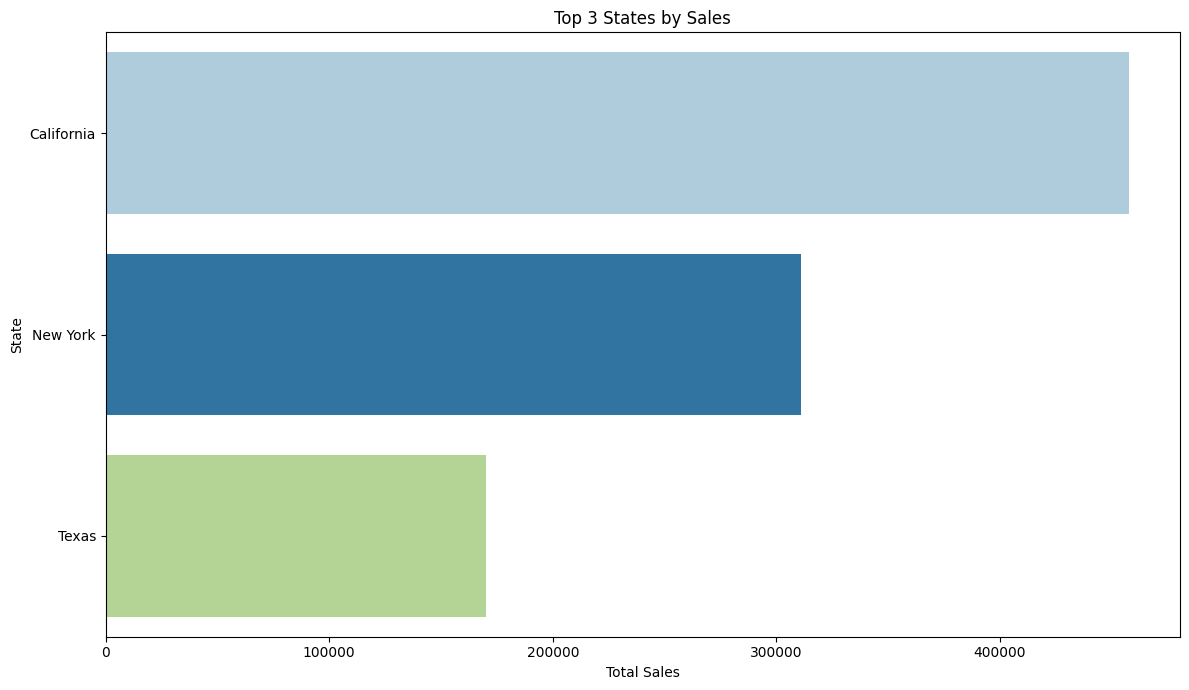

In [ ]:
#22.Top 3 states by Sales
plt.figure(figsize=(12,7))
StateSales = raw_data_3.groupby('State')['Sales'].sum().reset_index()
Top3StateSales = StateSales.nlargest(3, 'Sales')

sns.barplot(x='Sales', y='State', data=Top3StateSales, palette='Paired')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.title('Top 3 States by Sales')
plt.tight_layout()
plt.show()